In [1]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

creds, _ = default()
gc = gspread.authorize(creds)

In [2]:
# --- CELL 3: CONFIG ---------------------------------------------------------
SPREADSHEET_URL = "https://docs.google.com/spreadsheets/d/16MLPN8yEXCRy367SZRgM2aVHvLUiQD8JwD9P9Cl0QTw/edit"
OUTPUT_PNG = "coverage_combined.png"        # saved into the Colab session storage

SHEET_LOCATION = "location_coverage"
SHEET_LATLONG  = "lat_long_coverage"
SHEET_REGIME   = "water_regime"

COLOR_TOTAL   = "#B7C4DE"
COLOR_LATLONG = "#E64B35"
REGIME_COLORS = {"D": "#3C5488", "I": "#F39B7F", "B": "#00A087"}
COLOR_MISSING_REGIME = "#B0B0B0"

FIG_WIDTH = 3.5          # Nature single-column width (89 mm)
ROW_HEIGHT = 0.1
BAR_PANEL_HEIGHT = 0.55
DOT_SIZE = 20
BAR_TOTAL_WIDTH = 0.7
BAR_LATLONG_WIDTH = 0.38


In [3]:
# --- CELL 4: Nature-style rcParams ------------------------------------------
def set_nature_style():
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6,
        "axes.titlesize": 6.5,
        "axes.labelsize": 6.5,
        "xtick.labelsize": 5.5,
        "ytick.labelsize": 5.5,
        "legend.fontsize": 5.5,
        "axes.linewidth": 0.5,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "figure.dpi": 150,
        "savefig.dpi": 400,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    })


In [4]:
def load_sheet_from_gsheet(sh, sheet_name):
    """One worksheet -> DataFrame (locations as index, years as columns)."""
    ws = sh.worksheet(sheet_name)
    values = ws.get_all_values()               # list of rows, all strings
    df = pd.DataFrame(values[1:], columns=values[0])
    df = df.set_index(df.columns[0])
    df.columns = [c.strip() for c in df.columns]
    df.index = [i.strip() for i in df.index]
    df = df[df.index != ""]                    # drop blank trailing rows
    return df

In [5]:
def coerce_bool(df):
    return df.applymap(lambda v: str(v).strip().upper() in ("TRUE", "1", "YES", "X"))

In [6]:
def diagnose_access(spreadsheet_url):
    """Run this FIRST if you hit SpreadsheetNotFound. It tells you whether
    the problem is the URL/ID or the signed-in account's permissions."""
    import re
    m = re.search(r"/d/([a-zA-Z0-9-_]+)", spreadsheet_url)
    sheet_id = m.group(1) if m else None
    print("Parsed spreadsheet ID:", sheet_id)

    accessible = gc.list_spreadsheet_files()
    accessible_ids = {f["id"] for f in accessible}
    print(f"The authenticated account can see {len(accessible)} spreadsheet(s).")
    if sheet_id in accessible_ids:
        print("✅ This sheet IS visible to the signed-in account — ID is fine.")
    else:
        print("❌ This sheet is NOT in the signed-in account's visible list.")
        print("   -> Share the sheet with this Google account (Share button in "
              "Sheets), or sign into Colab with the account that owns it, "
              "then re-run auth.authenticate_user().")
    return sheet_id

In [7]:
def load_all_data(spreadsheet_url):
    sh = gc.open_by_url(spreadsheet_url)
    loc = coerce_bool(load_sheet_from_gsheet(sh, SHEET_LOCATION))
    ll = coerce_bool(load_sheet_from_gsheet(sh, SHEET_LATLONG))
    reg = load_sheet_from_gsheet(sh, SHEET_REGIME)
    reg = reg.applymap(lambda v: v.strip().upper() if v.strip() else np.nan)

    common_idx, common_cols = loc.index, loc.columns
    ll = ll.reindex(index=common_idx, columns=common_cols, fill_value=False)
    reg = reg.reindex(index=common_idx, columns=common_cols)
    return loc, ll, reg

In [8]:
# --- CELL 6: plotting (identical logic to the local-file version) ----------
def plot_combined(loc_df, ll_df, reg_df, output_path):
    set_nature_style()

    years = loc_df.columns.tolist()
    locations = loc_df.index.tolist()
    n_years, n_locs = len(years), len(locations)
    x = np.arange(n_years)

    total_per_year = loc_df.sum(axis=0).values
    latlong_per_year = ll_df.sum(axis=0).values

    dot_panel_h = n_locs * ROW_HEIGHT
    fig_h = 0.55 + BAR_PANEL_HEIGHT + dot_panel_h
    fig, (ax_bar, ax_dot) = plt.subplots(
        2, 1, sharex=True, figsize=(FIG_WIDTH, fig_h),
        gridspec_kw={"height_ratios": [BAR_PANEL_HEIGHT, dot_panel_h], "hspace": 0.05},
    )

    ax_bar.bar(x, total_per_year, width=BAR_TOTAL_WIDTH, color=COLOR_TOTAL,
               edgecolor="none", label="Total", zorder=2)
    ax_bar.bar(x, latlong_per_year, width=BAR_LATLONG_WIDTH, color=COLOR_LATLONG,
               edgecolor="none", label="Lat/long", zorder=3)
    ax_bar.set_ylabel("N locations", labelpad=2)
    ax_bar.set_ylim(0, max(total_per_year.max(), 1) * 1.15)
    ax_bar.tick_params(axis="y", pad=1)

    y_pos = {loc: n_locs - 1 - i for i, loc in enumerate(locations)}
    for regime, color in REGIME_COLORS.items():
        xs, ys = [], []
        for loc in locations:
            row_cov, row_reg = loc_df.loc[loc].values, reg_df.loc[loc].values
            for j in range(n_years):
                if row_cov[j] and str(row_reg[j]).upper() == regime:
                    xs.append(j); ys.append(y_pos[loc])
        ax_dot.scatter(xs, ys, s=DOT_SIZE, color=color, label=regime,
                        edgecolor="none", zorder=3)

    xs, ys = [], []
    for loc in locations:
        row_cov, row_reg = loc_df.loc[loc].values, reg_df.loc[loc].values
        for j in range(n_years):
            if row_cov[j] and str(row_reg[j]).upper() not in REGIME_COLORS:
                xs.append(j); ys.append(y_pos[loc])
    if xs:
        ax_dot.scatter(xs, ys, s=DOT_SIZE * 0.8, color=COLOR_MISSING_REGIME,
                        edgecolor="none", zorder=2, label="Unspec.")

    ax_dot.set_yticks(range(n_locs))
    ax_dot.set_yticklabels([locations[n_locs - 1 - i] for i in range(n_locs)])
    ax_dot.tick_params(axis="y", length=0, pad=2)
    ax_dot.tick_params(axis="x", pad=1)
    ax_dot.set_ylim(-0.7, n_locs - 0.3)
    ax_dot.set_xlabel("Year", labelpad=2)

    for i in range(n_locs):
        ax_dot.axhline(i, color="#EDEDED", linewidth=0.3, zorder=1)
    for spine in ("left", "bottom"):
        ax_dot.spines[spine].set_linewidth(0.5)

    step = max(1, n_years // 10)
    ax_dot.set_xticks(x[::step])
    ax_dot.set_xticklabels([years[i] for i in range(0, n_years, step)], rotation=45, ha="right")
    ax_dot.set_xlim(-0.7, n_years - 0.3)

    bar_handles, bar_labels = ax_bar.get_legend_handles_labels()
    dot_handles, dot_labels = ax_dot.get_legend_handles_labels()
    legend = ax_bar.legend(
        bar_handles + dot_handles, bar_labels + dot_labels,
        loc="lower center", ncol=len(bar_labels + dot_labels),
        bbox_to_anchor=(0.5, 1.02), bbox_transform=ax_bar.transAxes,
        frameon=False, handlelength=0.8, handletextpad=0.3,
        columnspacing=0.9, markerscale=1.3, borderaxespad=0.2,
    )

    fig.savefig(output_path, bbox_extra_artists=(legend,))
    plt.show()   # inline display in Colab
    print(f"Saved -> {output_path}  (see the Colab Files panel on the left)")

/tmp/ipykernel_13663/944364296.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda v: str(v).strip().upper() in ("TRUE", "1", "YES", "X"))
/tmp/ipykernel_13663/3940745628.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  reg = reg.applymap(lambda v: v.strip().upper() if v.strip() else np.nan)


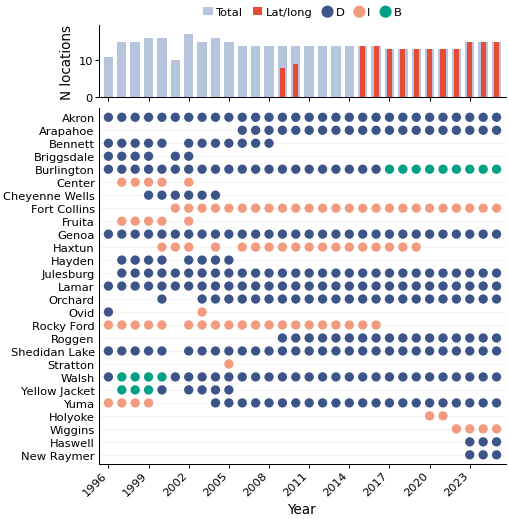

Saved -> coverage_combined.png  (see the Colab Files panel on the left)


In [9]:
loc_df, ll_df, reg_df = load_all_data(SPREADSHEET_URL)
plot_combined(loc_df, ll_df, reg_df, OUTPUT_PNG)

In [10]:
from google.colab import files
files.download(OUTPUT_PNG)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>